In [1]:
import openpyxl
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
import csv
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk import word_tokenize, bigrams
from nltk.corpus import stopwords
from collections import Counter
nltk.download('punkt')
# Download das stopwords em português se ainda não estiverem baixadas
nltk.download('stopwords')
nltk.download('punkt')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:


def procurar_e_imprimir(textos, termos):
    nltk.download('punkt')
    resultados = {termo: [] for termo in termos}
    textos_utilizados = set()

    for termo in termos:
        bigramas_termo = list(bigrams(termo.lower().split()))
        textos_encontrados = 0

        for texto in textos:
            if texto['text'] in textos_utilizados:
                continue

            texto_lower = texto['text'].lower()
            palavras_texto = word_tokenize(texto_lower)
            bigramas_texto = list(bigrams(palavras_texto))
            count = sum(1 for bigrama in bigramas_termo if bigrama in bigramas_texto)

            if count >= 4:  # Verifica se pelo menos 4 bigramas do termo estão no texto
                texto['correspondencia'] = count
                resultados[termo].append(texto)
                textos_utilizados.add(texto['text'])
                textos_encontrados += 1

    return resultados

def main():
    # Carregar termos da coluna da planilha .xlsx
    wb = openpyxl.load_workbook('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//noticias_falsas_verificadas_coletadas.xlsx')
    planilha = wb['Outubro']
    
    # Extrair termos-chave da coluna 'Termos_chave' (coluna D)
    termos = [celula.value for celula in planilha['D'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_0.csv', 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_with_bigrams_out_2022_cluster_0.xlsx', index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [4]:


def procurar_e_imprimir(textos, termos):
    nltk.download('punkt')
    resultados = {termo: [] for termo in termos}
    textos_utilizados = set()

    for termo in termos:
        bigramas_termo = list(bigrams(termo.lower().split()))
        textos_encontrados = 0

        for texto in textos:
            if texto['text'] in textos_utilizados:
                continue

            texto_lower = texto['text'].lower()
            palavras_texto = word_tokenize(texto_lower)
            bigramas_texto = list(bigrams(palavras_texto))
            count = sum(1 for bigrama in bigramas_termo if bigrama in bigramas_texto)

            if count >= 4:  # Verifica se pelo menos 4 bigramas do termo estão no texto
                texto['correspondencia'] = count
                resultados[termo].append(texto)
                textos_utilizados.add(texto['text'])
                textos_encontrados += 1

            
    return resultados

def main():
    # Carregar termos da coluna da planilha .xlsx
    wb = openpyxl.load_workbook('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//noticias_falsas_verificadas_coletadas.xlsx')
    planilha = wb['Outubro']
    
    # Extrair termos-chave da coluna 'Termos_chave' (coluna D)
    termos = [celula.value for celula in planilha['D'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_1.csv', 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_with_bigrams_out_2022_cluster_1.xlsx', index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [93]:
def contar_termos_com_desinformacao(df):
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df[df['desinformacao'].str.lower() == 'sim']
    
    # Contar a frequência dos termos nos textos com desinformação
    termo_counts = df_desi_texts['termo'].value_counts()
    
    return termo_counts

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Contar os termos que possuem "sim" na coluna desinformacao
    termo_counts = contar_termos_com_desinformacao(df_desi)
    
    # Ordenar e selecionar os top 5 termos mais frequentes
    top_5_termos = termo_counts.head(5)
    
    # Exibir os 5 termos mais frequentes com desinformação
    for termo, count in top_5_termos.items():
        print(f"Termo: {termo}, Quantidade de Desinformação: {count}")

if __name__ == "__main__":
    main()


Termo: eleitores apertam 22 e aparece 13, votaram em células de papel, ser no preso no brasil, direito a ser presidente, tem máquina que povo vota 22 e dá 13, estão votando no papel, Quantidade de Desinformação: 95
Termo: Odisseia FM 104.9, Brigada Militar de Serafina Corrêa aprendeu,urnas eletrônicas no carro de Thiago Feronato,urnas estavam preenchida com voto para o Lula PT, golpe contra o Bolsonaro, Quantidade de Desinformação: 58
Termo: O ITA e o IME irão fazer a auditoria, exército solicita o código fonte, fraude e os caras zoavam,Ele sacaneava a imprensa, ele tem a fraude na mão,Esqueceram do voto de rebanho, o senador não vota no presidente, como é que o cara vota em você, vota no governador e não vota no presidente, Quantidade de Desinformação: 36
Termo: A globo está tentando esconder, era para o PT ter ganhado, esquema da fraude, descontando votos de bolsonaro, exército interviu quando quem estava monitorando a fraude, inteligência russa,descobriram o padrão da fraude, Do car

In [94]:
def contar_termos_com_desinformacao(df):
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df[df['desinformacao'].str.lower() == 'sim']
    
    # Contar a frequência dos termos nos textos com desinformação
    termo_counts = df_desi_texts['termo'].value_counts()
    
    return termo_counts

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Imprimir textos com maior correspondência (coluna correspondencia)
    top_textos = df_desi.sort_values(by='correspondencia', ascending=False).head(5)
    print("\nTextos com Maior Correspondência:")
    for idx, row in top_textos.iterrows():
        print(f"Texto: {row['text']}, Correspondência: {row['correspondencia']}")
        
        # Calcular a média da correspondência dos top textos
    media_correspondencia = top_textos['correspondencia'].mean()
    print(f"\nMédia da Correspondência dos Top Textos: {media_correspondencia}")
    
    # Calcular a média da correspondência de todos os textos
    media_correspondencia = df_desi['correspondencia'].mean()
    print(f"\nMédia da Correspondência de Todos os Textos: {media_correspondencia}")

if __name__ == "__main__":
    main()



Textos com Maior Correspondência:
Texto: @folha Pra quem defende voto impresso falando isso e por que quer causar algum tipo de revolta. Revolta essa que visa desacreditar na tecnologia. O mito é um fanfaram que não quer perder as eleições e alega fraude sem provas., Correspondência: 9
Texto: @juliovschneider Aos eleitores do Bozonaro que não estão satisfeitos com o resultado da eleição sugiro ir morar no Afeganistão... Lá não tem STF, não tem urna eletrônica, o voto é impresso, não tem congresso, o pessoal anda armado e... Adivinha? Fazem tudo em nome de Deus, Correspondência: 8
Texto: @lavern_spicer é que aqui não tem mais voto impresso como faziam os povos maias, astecas e incas, Correspondência: 8
Texto: @Silvio_MKT Silvio, não estamos generalizando, nossa intenção é coibir ao máximo as tentativas de fraude, e por isso a Lei prevê o voto impresso assim., Correspondência: 8
Texto: Jovem de 22 anos cola teclas de urna eletrônica no Mato Grosso com cola de alta resistência e impede t

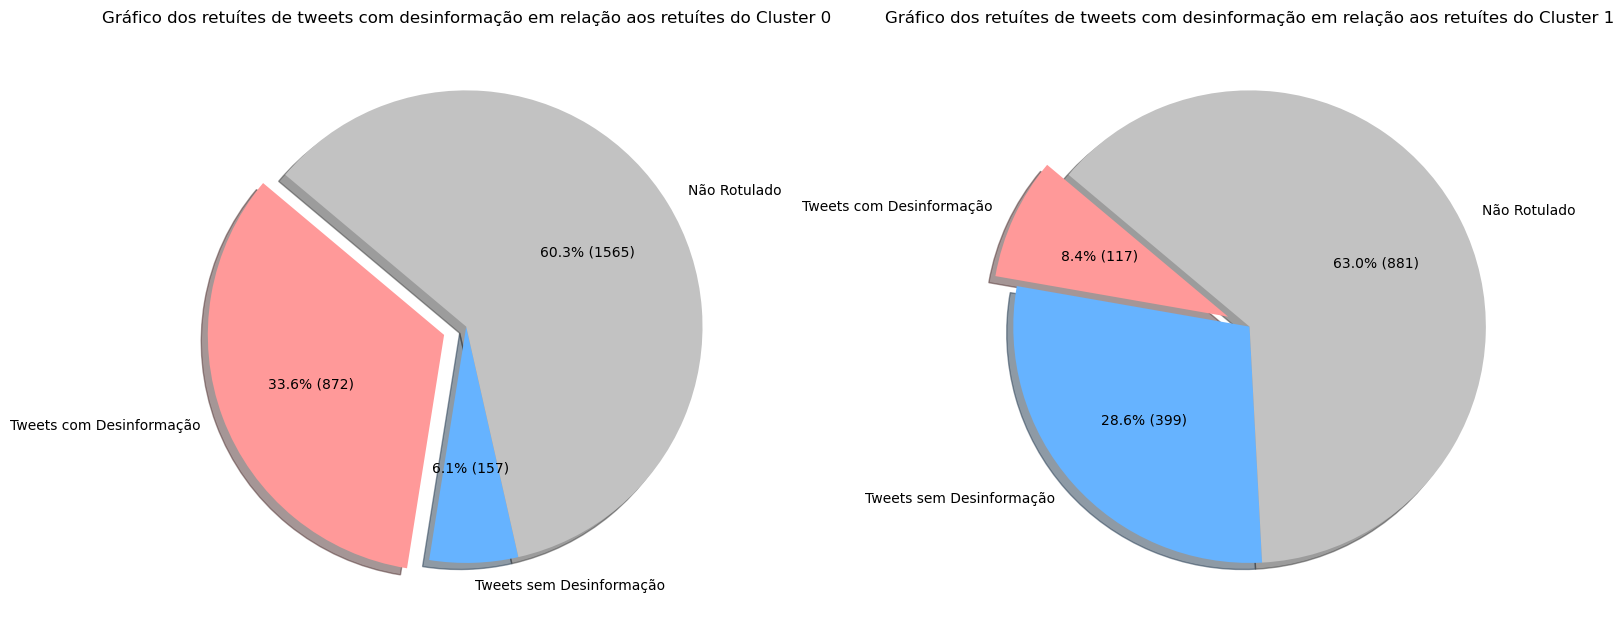

In [2]:

def criar_grafico_desinformacao(df_cluster, df_desi, ax, titulo):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar contadores
    total_textos = df_cluster_unique.shape[0]
    desinformacao_count = 0
    nao_rotulado_count = 0
    
    # Iterar sobre os textos únicos no cluster
    for text in df_cluster_unique['text']:
        if text in df_desi['text'].values:
            desinformacao_status = df_desi[df_desi['text'] == text]['desinformacao'].values[0]
            if pd.isna(desinformacao_status):
                nao_rotulado_count += 1
            else:
                desinformacao_status = desinformacao_status.strip().lower()
                if desinformacao_status == 'sim':
                    desinformacao_count += 1
                elif desinformacao_status == 'não' or desinformacao_status == 'nao':
                    pass  # "não" é considerado como sem desinformação
        else:
            nao_rotulado_count += 1

    # Calcular a porcentagem de desinformação
    total_rotulado = total_textos - nao_rotulado_count
    porcentagem_desinformacao = (desinformacao_count / total_rotulado) * 100 if total_rotulado > 0 else 0
    
    # Criar gráfico de pizza
    labels = ['Tweets com Desinformação', 'Tweets sem Desinformação', 'Não Rotulado']
    sizes = [desinformacao_count, total_rotulado - desinformacao_count, nao_rotulado_count]
    colors = ['#ff9999', '#66b3ff', '#c2c2c2']
    explode = (0.1, 0, 0)  # Explode 1st slice
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct=lambda p: f'{p:.1f}% ({int(p * total_textos / 100):d})', shadow=True, startangle=140)
    ax.set_title(titulo)

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_0.csv')
    df_cluster_1 = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_1.csv')
    
    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_0')
    df_desi_1 = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos
    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0')
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1')

    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


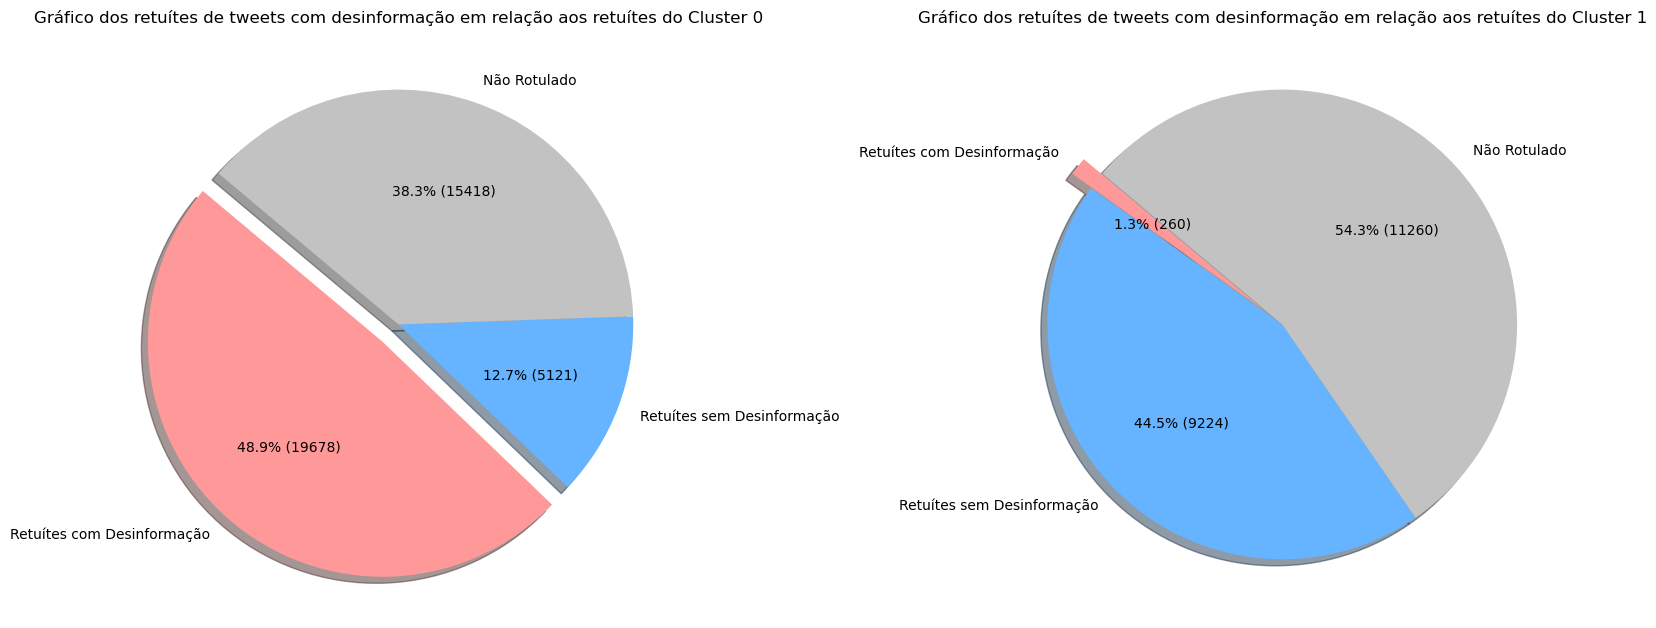

In [5]:
def criar_grafico_desinformacao(df_cluster, df_desi, ax, titulo):
    # Inicializar contadores
    total_textos = df_cluster.shape[0]
    desinformacao_count = 0
    nao_rotulado_count = 0
    
    # Iterar sobre todos os textos no cluster
    for text in df_cluster['text']:
        if text in df_desi['text'].values:
            desinformacao_status = df_desi[df_desi['text'] == text]['desinformacao'].values[0]
            if pd.isna(desinformacao_status):
                nao_rotulado_count += 1
            else:
                desinformacao_status = desinformacao_status.strip().lower()
                if desinformacao_status == 'sim':
                    desinformacao_count += 1
                elif desinformacao_status == 'não' or desinformacao_status == 'nao':
                    pass  # "não" é considerado como sem desinformação
        else:
            nao_rotulado_count += 1

    # Calcular a porcentagem de desinformação
    total_rotulado = total_textos - nao_rotulado_count
    porcentagem_desinformacao = (desinformacao_count / total_rotulado) * 100 if total_rotulado > 0 else 0
    
    # Criar gráfico de pizza
    labels = ['Retuítes com Desinformação', 'Retuítes sem Desinformação', 'Não Rotulado']
    sizes = [desinformacao_count, total_rotulado - desinformacao_count, nao_rotulado_count]
    colors = ['#ff9999', '#66b3ff', '#c2c2c2']
    explode = (0.1, 0, 0)  # Explode 1st slice
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct=lambda p: f'{p:.1f}% ({int(p * total_textos / 100):d})', shadow=True, startangle=140)
    ax.set_title(titulo)

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_0.csv')
    df_cluster_1 = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_1.csv')
    
    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_0')
    df_desi_1 = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos

    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0')
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1')
    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


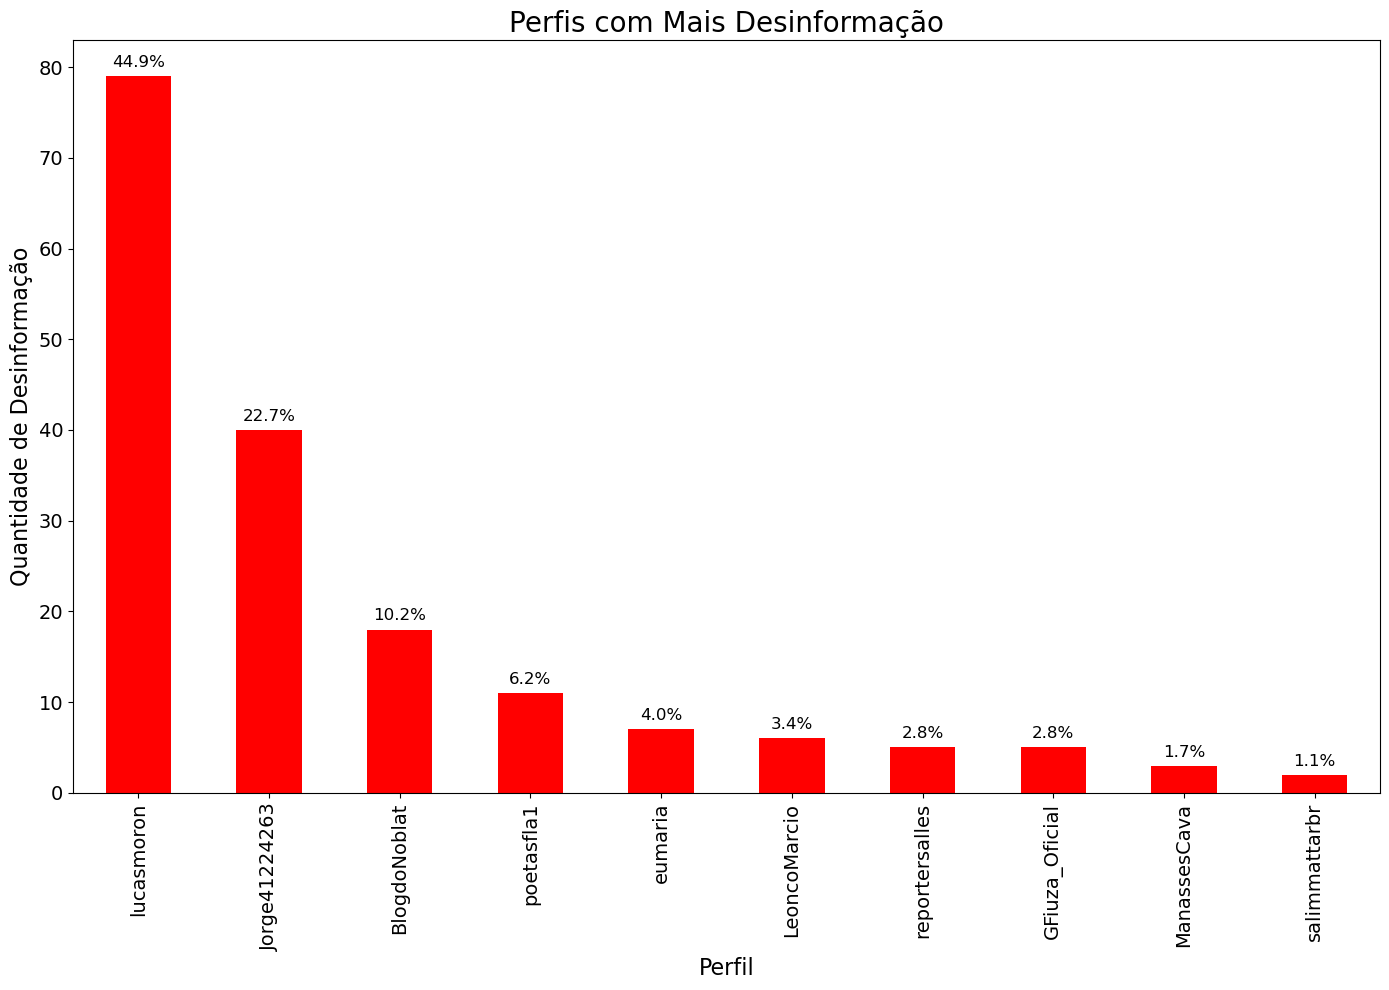

In [19]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Identificar textos com desinformação (considerando todas as ocorrências)
    df_desi_texts = df_desi[df_desi['desinformacao'].str.lower() == 'sim']
    textos_com_desi = df_desi_texts['text']
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts_cluster = df_cluster[df_cluster['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts_cluster['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(14, 10))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação', fontsize=20)
    plt.xlabel('Perfil', fontsize=16)
    plt.ylabel('Quantidade de Desinformação', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_1.csv')
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


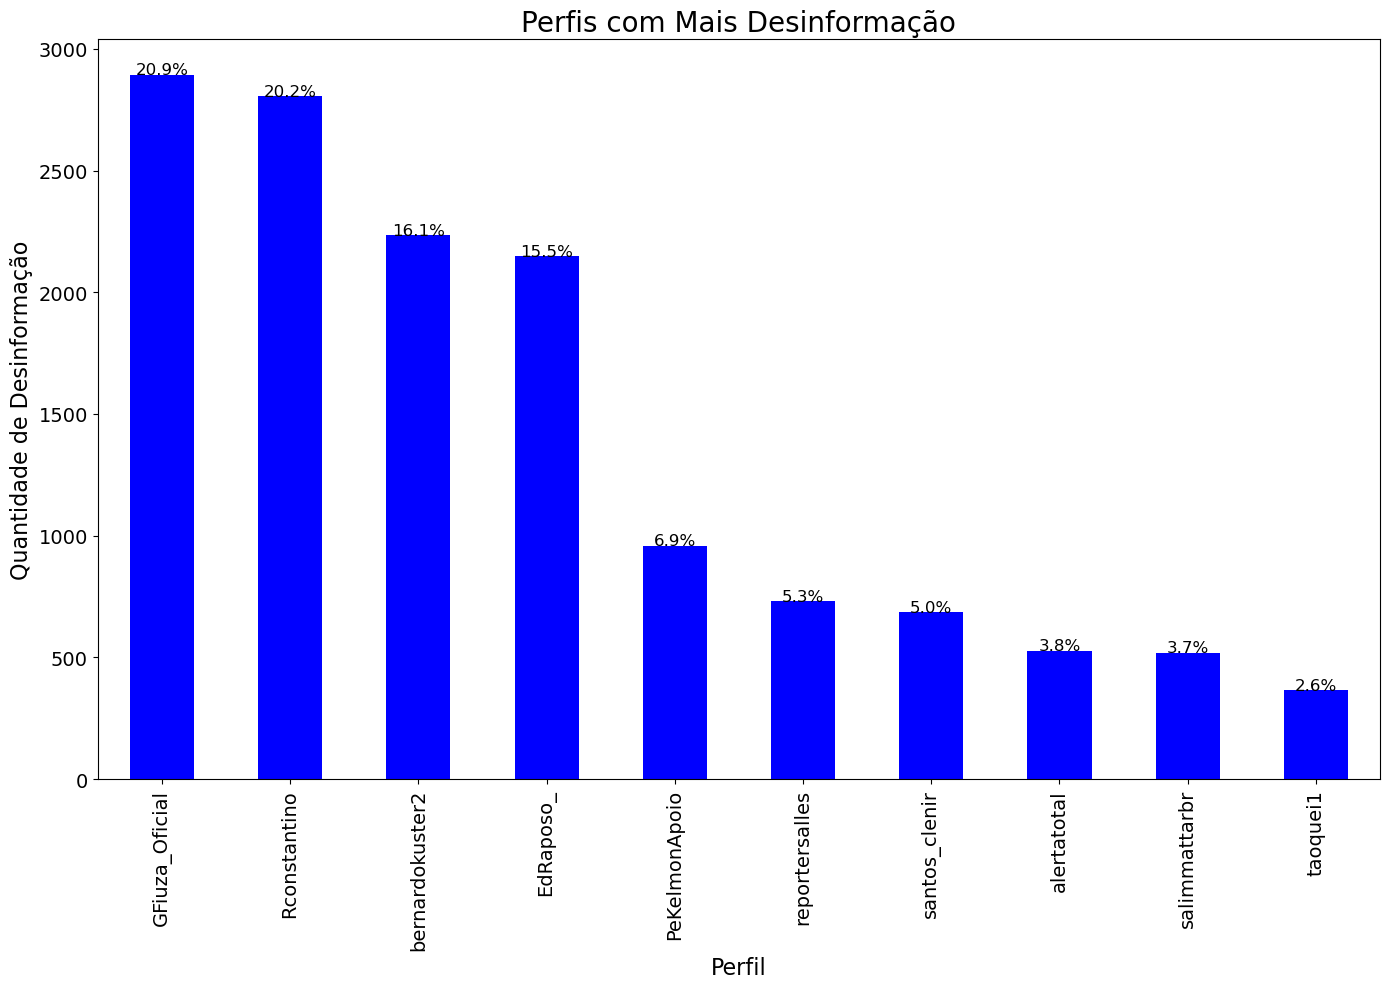

In [20]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Identificar textos com desinformação (considerando todas as ocorrências)
    df_desi_texts = df_desi[df_desi['desinformacao'].str.lower() == 'sim']
    textos_com_desi = df_desi_texts['text']
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts_cluster = df_cluster[df_cluster['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts_cluster['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(14, 10))
    bars = perfil_counts.plot(kind='bar', color='blue')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação', fontsize=20)
    plt.xlabel('Perfil', fontsize=16)
    plt.ylabel('Quantidade de Desinformação', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_0.csv')
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_0')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


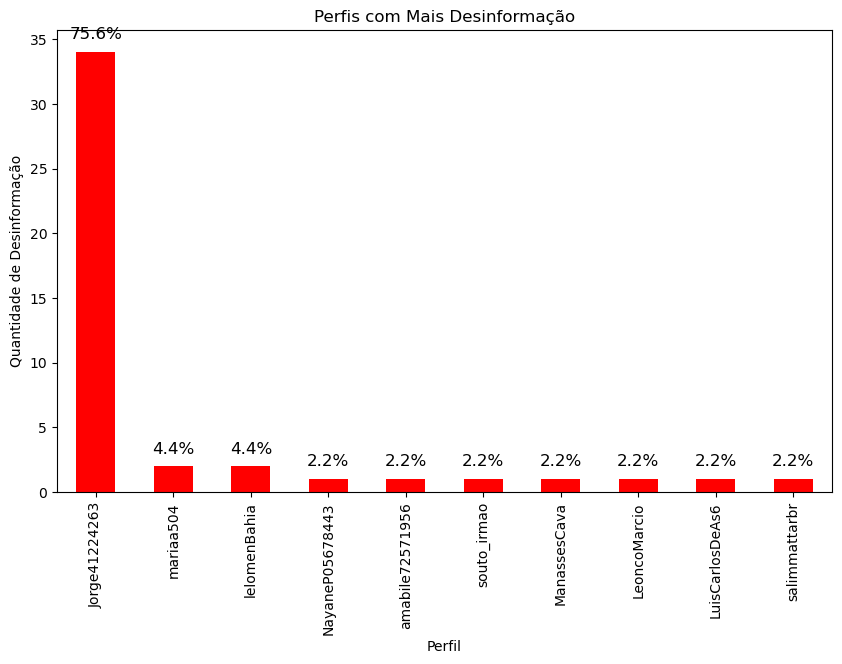

In [21]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar lista de textos com desinformação
    textos_com_desi = []
    
    # Adicionar todos os textos da planilha com desinformação 'sim'
    for text in df_cluster_unique['text']:
        if df_desi[(df_desi['text'] == text) & (df_desi['desinformacao'].str.lower() == 'sim')].shape[0] > 0:
            textos_com_desi.append(text)
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df_cluster_unique[df_cluster_unique['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(10, 6))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação')
    plt.xlabel('Perfil')
    plt.ylabel('Quantidade de Desinformação')
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_1.csv')
    
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


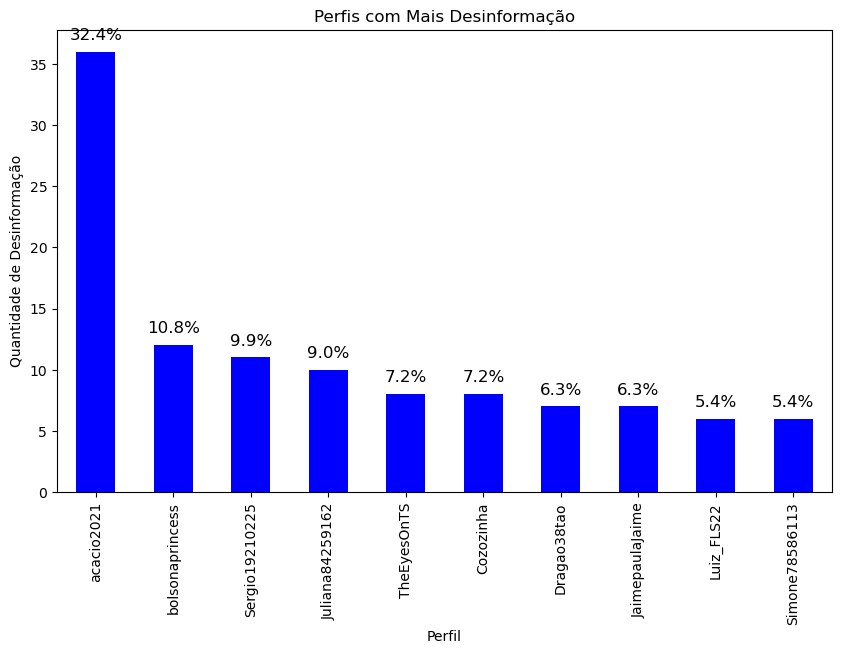

In [22]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar lista de textos com desinformação
    textos_com_desi = []
    
    # Adicionar todos os textos da planilha com desinformação 'sim'
    for text in df_cluster_unique['text']:
        if df_desi[(df_desi['text'] == text) & (df_desi['desinformacao'].str.lower() == 'sim')].shape[0] > 0:
            textos_com_desi.append(text)
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df_cluster_unique[df_cluster_unique['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(10, 6))
    bars = perfil_counts.plot(kind='bar', color='blue')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação')
    plt.xlabel('Perfil')
    plt.ylabel('Quantidade de Desinformação')
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster = pd.read_csv('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//clusters_TM//Oct_2022_cluster_0.csv')
    
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_0')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


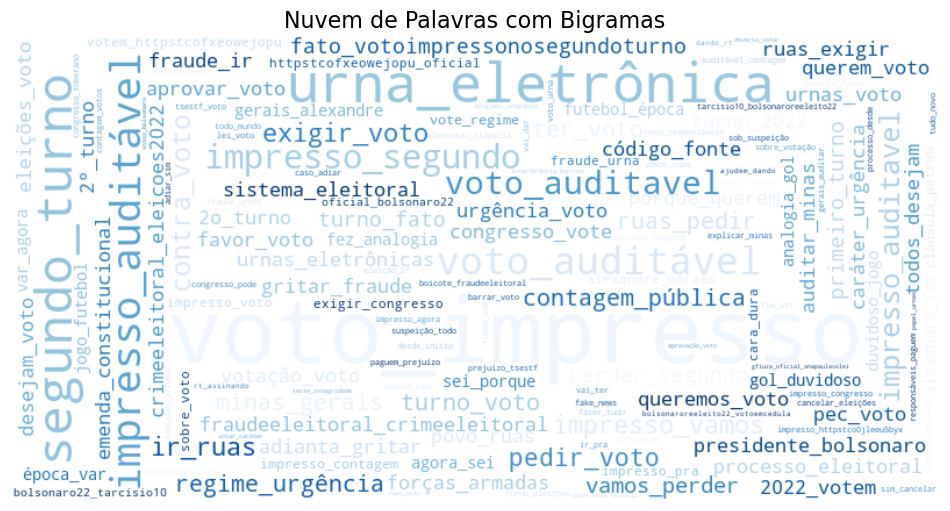

In [10]:
def extrair_bigramas(textos, termos):
    # Tokenizar os textos em palavras, removendo vírgulas
    textos_tokenizados = [word_tokenize(re.sub(r'[^\w\s]', '', texto.lower())) for texto in textos]
    
    # Lista de stopwords em português
    stop_words = set(stopwords.words('portuguese'))
    
    # Inicializar lista para armazenar bigramas
    bigram_list = []
    
    # Formar bigramas com base nos textos, ignorando stopwords e palavras isoladas
    for texto_tokenizado in textos_tokenizados:
        filtered_texto = [word for word in texto_tokenizado if word not in stop_words and len(word) > 1]
        bigram_list.extend(list(bigrams(filtered_texto)))
    
    # Contar a frequência dos bigramas nos textos
    bigram_counts = Counter()
    for bigram in bigram_list:
        bigram_counts['_'.join(bigram)] += 1
    
    return bigram_counts

def criar_nuvem_de_palavras(bigram_counts):
    if len(bigram_counts) == 0:
        print("Não foram encontrados bigramas nos textos.")
        return
    
    # Obter os 150 bigramas mais frequentes
    top_bigrams = bigram_counts.most_common(150)
    
    # Preparar os dados para a nuvem de palavras
    wordcloud_dict = {bigram.replace(' ', '_'): count for bigram, count in bigram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=150, prefer_horizontal=0.8)
    wordcloud.generate_from_frequencies(wordcloud_dict)
    
    # Definir estilos para os bigramas mais frequentes
    default_style = {
        'font_size': 12,
        'color': 'black',
        'regexp': r'\w[\w\s]*\w'
    }
    
    # Estilos modificados para os top bigramas
    highlighted_style = {
        **default_style,
        'font_size': 30,
        'color': 'blue',
        'font_path': None,
        'bold': True,
        'italic': True,
        'collocations': False
    }
    
    # Atualizar o estilo para os bigramas mais frequentes
    for bigram, _ in top_bigrams:
        wordcloud_dict[bigram.replace(' ', '_')] = 1
    
    # Plotar a nuvem de palavras
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras com Bigramas', fontsize=16)
    plt.show()

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_0')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


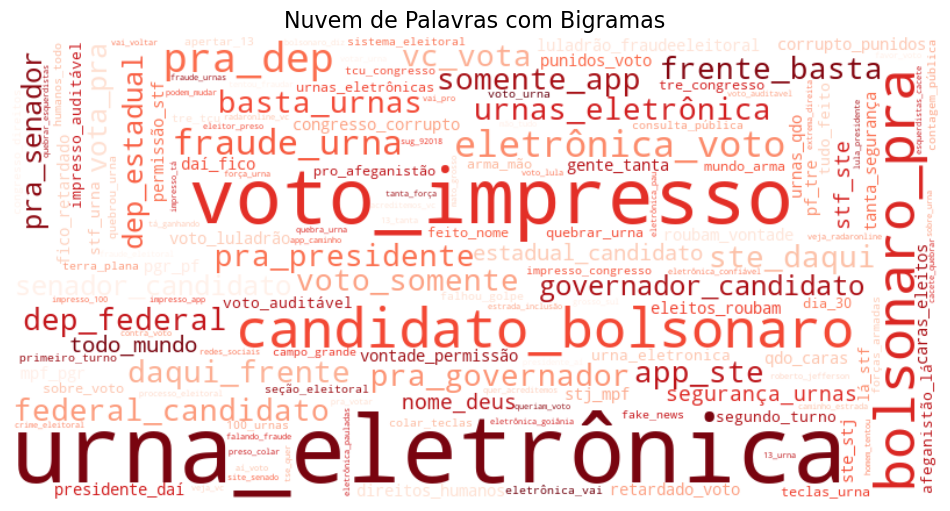

In [11]:
def extrair_bigramas(textos, termos):
    # Tokenizar os textos em palavras, removendo vírgulas
    textos_tokenizados = [word_tokenize(re.sub(r'[^\w\s]', '', texto.lower())) for texto in textos]
    
    # Lista de stopwords em português
    stop_words = set(stopwords.words('portuguese'))
    
    # Inicializar lista para armazenar bigramas
    bigram_list = []
    
    # Formar bigramas com base nos textos, ignorando stopwords e palavras isoladas
    for texto_tokenizado in textos_tokenizados:
        filtered_texto = [word for word in texto_tokenizado if word not in stop_words and len(word) > 1]
        bigram_list.extend(list(bigrams(filtered_texto)))
    
    # Contar a frequência dos bigramas nos textos
    bigram_counts = Counter()
    for bigram in bigram_list:
        bigram_counts['_'.join(bigram)] += 1
    
    return bigram_counts

def criar_nuvem_de_palavras(bigram_counts):
    if len(bigram_counts) == 0:
        print("Não foram encontrados bigramas nos textos.")
        return
    
    # Obter os 150 bigramas mais frequentes
    top_bigrams = bigram_counts.most_common(150)
    
    # Preparar os dados para a nuvem de palavras
    wordcloud_dict = {bigram.replace(' ', '_'): count for bigram, count in bigram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=150, prefer_horizontal=0.8)
    wordcloud.generate_from_frequencies(wordcloud_dict)
    
    # Definir estilos para os bigramas mais frequentes
    default_style = {
        'font_size': 12,
        'color': 'black',
        'regexp': r'\w[\w\s]*\w'
    }
    
    # Estilos modificados para os top bigramas
    highlighted_style = {
        **default_style,
        'font_size': 30,
        'color': 'blue',
        'font_path': None,
        'bold': True,
        'italic': True,
        'collocations': False
    }
    
    # Atualizar o estilo para os bigramas mais frequentes
    for bigram, _ in top_bigrams:
        wordcloud_dict[bigram.replace(' ', '_')] = 1
    
    # Plotar a nuvem de palavras
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras com Bigramas', fontsize=16)
    plt.show()

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel('C://Users//pc//Desktop//Pdpd_2023//Oct_2022//texto_encontrados_out_2022.xlsx', sheet_name='Cluster_1')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()
